In [1]:
# Part 1
# 1.1
%pip install opencv-python
%pip install matplotlib
%pip install numpy pandas

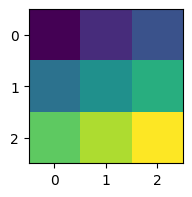

In [6]:

# 1.2 Import & Validate
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

plt.figure(figsize=(2, 2))
plt.imshow(test)
plt.show()


In [8]:
# Part 2
# Task 1:
class GroceryManager:

    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        self.items[item] = {
            "quantity": quantity,
            "price": price
        }

    def remove_item(self, item):
        if item in self.items:
            del self.items[item]
        else:
            print("Item not found.")

    def view_list(self):
        if not self.items:
            print("Grocery list is empty.")
            return

        for item, details in self.items.items():
            print(item, "-", details["quantity"], "x", details["price"])

    def calculate_total(self):
        total = 0

        for details in self.items.values():
            total += details["quantity"] * details["price"]

        return total



manager = GroceryManager()

manager.add_item("Milk", 2, 280)
manager.add_item("Bread", 1, 150)
manager.add_item("Eggs", 12, 25)

manager.view_list()

print("Total cost:", manager.calculate_total())

manager.remove_item("Bread")
manager.view_list()


Milk - 2 x 280
Bread - 1 x 150
Eggs - 12 x 25
Total cost: 1010
Milk - 2 x 280
Eggs - 12 x 25


In [9]:
# Task 2
students = {
    "1": {
        "Name": "Raghib",
        "Major": "Artificial Intelligence",
        "Grades": [0, 2, 9, 5]
    },
    "2": {
        "Name": "Umar",
        "Major": "Computer Science",
        "Grades": [72, 68, 80, 75]
    },
    "3": {
        "Name": "Fahad",
        "Major": "Artificial Intelligence",
        "Grades": [95, 91, 98, 89]
    }
}


def top_student(records):
    highest_average = 0
    top_name = ""

    for student in records.values():
        average = sum(student["Grades"]) / len(student["Grades"])

        if average > highest_average:
            highest_average = average
            top_name = student["Name"]

    return top_name


def search_by_major(records, major):
    for student in records.values():
        if student["Major"] == major:
            print(student["Name"])


print("Student with highest average:", top_student(students))

print("\nStudents in Artificial Intelligence:")
search_by_major(students, "Artificial Intelligence")

Student with highest average: Fahad

Students in Artificial Intelligence:
Raghib
Fahad


## Part 3: Core Computer Vision & Matplotlib

> All image visualization tasks use Matplotlib subplots for side-by-side comparisons unless stated otherwise.

### Image paths and safe loader

Edit `IMAGE_PATH`, `HIGH_RES_PATH`, `DOC_PATH`, `IMAGE_A`, `IMAGE_B` to point at your own files.

In [ ]:
# Part 3

IMAGE_PATH    = 'Sukuna.jpeg'      # Task 3
HIGH_RES_PATH = 'Sukuna.jpeg'      # Task 5 (use a large image if you have one)
CAPTION_PATH  = 'Sukuna.jpeg'      # Task 6
DOC_PATH      = 'document.jpg'     # Task 7 (grayscale document / high-contrast image)
IMAGE_A       = 'Sukuna.jpeg'      # Task 8
IMAGE_B       = 'Gojo.jpeg'        # Task 8


def make_sample_image(width=800, height=600, seed=0):
    # Generates a synthetic BGR image so every cell runs even without your own files.
    yy, xx = np.mgrid[0:height, 0:width]
    b = (255 * (xx / max(width - 1, 1))).astype(np.uint8)
    g = (255 * (yy / max(height - 1, 1))).astype(np.uint8)
    r = (127 + 127 * np.sin(2 * np.pi * (xx + yy) / (90 + 30 * seed))).astype(np.uint8)
    img = np.dstack([b, g, r])

    # A few hard-edged shapes so blurring and thresholding have something to act on.
    cv2.circle(img, (width // 2, height // 2), min(width, height) // 4, (255, 255, 255), -1)
    cv2.rectangle(img, (40, 40), (width // 4, height // 4), (0, 0, 0), -1)
    cv2.putText(img, "SAMPLE", (int(0.22 * width), int(0.88 * height)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 5)
    return img


def load_image_safe(path, fallback=True, **kwargs):
    # Implements the required safety check, with an optional generated fallback.
    image = cv2.imread(path)
    if image is None:
        print(f"Error: Image not found.  (looked for: {path})")
        if fallback:
            print("  -> Substituting a generated sample image so the cell still runs.")
            return make_sample_image(**kwargs)
        return None
    print(f"Loaded '{path}' with shape {image.shape}")
    return image

### Task 3: Safe Image Loading & RGB Visualization

OpenCV reads images in **BGR** order; Matplotlib expects **RGB**, so displaying an
unconverted OpenCV image shows inverted colors (reds and blues swapped).

In [ ]:
image = cv2.imread(IMAGE_PATH)

if image is None:
    print("Error: Image not found.")
    print("  -> Substituting a generated sample image for demonstration.")
    image = make_sample_image()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
plt.show()

**Optional demonstration of the BGR/RGB problem** — the same array with and without conversion.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)          # raw BGR handed to Matplotlib -> wrong colors
axes[0].set_title('BGR passed directly (wrong)', fontsize=14, color='darkred')
axes[0].axis('off')

axes[1].imshow(image_rgb)      # converted -> correct colors
axes[1].set_title('Converted to RGB (correct)', fontsize=14, color='darkgreen')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 4: Interactive Geometry & Blank Canvas

An 800x800 black canvas, a five-ring target board in alternating colors, a bounding box
around the outermost ring, and the exact center coordinates printed.

In [ ]:
CANVAS_SIZE = 800
canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8)

center_x = CANVAS_SIZE // 2
center_y = CANVAS_SIZE // 2
center = (center_x, center_y)

# Five concentric circles, drawn largest first so smaller ones sit on top.
# Colors are BGR tuples, alternating red / white.
radii  = [350, 280, 210, 140, 70]
colors = [(0, 0, 255), (255, 255, 255), (0, 0, 255), (255, 255, 255), (0, 0, 255)]

for radius, color in zip(radii, colors):
    cv2.circle(canvas, center, radius, color, thickness=-1)   # -1 = filled

# Bounding box around the outermost circle.
outer_radius = radii[0]
top_left     = (center_x - outer_radius, center_y - outer_radius)
bottom_right = (center_x + outer_radius, center_y + outer_radius)
cv2.rectangle(canvas, top_left, bottom_right, (0, 255, 0), thickness=4)

print(f"Canvas size          : {CANVAS_SIZE} x {CANVAS_SIZE}")
print(f"Exact center (x, y)  : {center}")
print(f"Outer circle radius  : {outer_radius}")
print(f"Bounding box         : top-left {top_left}, bottom-right {bottom_right}")

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8))
axes[0].set_title('Blank 800x800 Canvas', fontsize=14, color='navy')
axes[0].axis('off')

axes[1].imshow(canvas_rgb)
axes[1].set_title('Target Board + Bounding Box', fontsize=14, color='darkgreen')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 5: Advanced Blurring & NumPy ROI Extraction

A 25x25 Gaussian kernel (odd sizes are required by `cv2.GaussianBlur`), then a
300x300 center crop taken from both the original and the blurred image via array slicing.

In [ ]:
hi_res = load_image_safe(HIGH_RES_PATH, width=1200, height=900)
hi_res_rgb = cv2.cvtColor(hi_res, cv2.COLOR_BGR2RGB)

# Heavy Gaussian blur. Kernel dimensions must be positive and odd.
blurred_rgb = cv2.GaussianBlur(hi_res_rgb, (25, 25), 0)

ROI_SIZE = 300
h, w = hi_res_rgb.shape[:2]

if h < ROI_SIZE or w < ROI_SIZE:
    raise ValueError(f"Image is {w}x{h}; needs to be at least {ROI_SIZE}x{ROI_SIZE} for the ROI.")

# Exact-center slice bounds.
start_y = (h - ROI_SIZE) // 2
start_x = (w - ROI_SIZE) // 2
end_y   = start_y + ROI_SIZE
end_x   = start_x + ROI_SIZE

roi_original = hi_res_rgb[start_y:end_y, start_x:end_x]
roi_blurred  = blurred_rgb[start_y:end_y, start_x:end_x]

print(f"Full image      : {w} x {h}")
print(f"ROI slice rows  : {start_y}:{end_y}")
print(f"ROI slice cols  : {start_x}:{end_x}")
print(f"ROI shape       : {roi_original.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(roi_original)
axes[0].set_title('Original ROI (300x300)', fontsize=15, color='darkblue')
axes[0].axis('off')

axes[1].imshow(roi_blurred)
axes[1].set_title('Gaussian Blurred ROI (25x25)', fontsize=15, color='darkred')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 6: Alpha Blending & Typography

A blue bar over the bottom 20% of the image, blended semi-transparently with
`cv2.addWeighted`, with a caption written over it.

In [ ]:
caption_img = load_image_safe(CAPTION_PATH)
caption_img = caption_img.copy()
h, w = caption_img.shape[:2]

# Solid color overlay: same size as the image, with a filled rectangle over the bottom 20%.
overlay = caption_img.copy()
bar_top = int(h * 0.80)
cv2.rectangle(overlay, (0, bar_top), (w, h), (200, 80, 0), thickness=-1)   # BGR blue

# Semi-transparent blend: alpha on the original, beta on the overlay.
alpha = 0.6
beta  = 1 - alpha
blended = cv2.addWeighted(caption_img, alpha, overlay, beta, 0)

# Caption text over the transparent box.
text = "King of Curses"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = max(w / 700.0, 0.6)
thickness = max(int(font_scale * 2), 1)

(text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
text_x = (w - text_w) // 2
text_y = bar_top + (h - bar_top + text_h) // 2

cv2.putText(blended, text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(cv2.cvtColor(caption_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontsize=15, color='black')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
axes[1].set_title('Alpha-Blended Caption Bar', fontsize=15, color='darkblue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 7: Matrix-Based Rotation & Adaptive Thresholding

Global binary thresholding uses one cutoff for the whole image; adaptive thresholding
computes a separate cutoff per neighbourhood, which handles uneven lighting far better.
The adaptive output is then rotated 45 degrees with a scale factor of 0.8 so the
corners stay inside the frame.

In [ ]:
doc = load_image_safe(DOC_PATH, width=800, height=600, seed=1)
gray = cv2.cvtColor(doc, cv2.COLOR_BGR2GRAY)

# 1) Global binary threshold - single cutoff at 127.
_, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2) Adaptive threshold - cutoff computed per 11x11 neighbourhood, minus a constant of 2.
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=2
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale', fontsize=14, color='black')
axes[0].axis('off')

axes[1].imshow(global_thresh, cmap='gray')
axes[1].set_title('Global Binary Threshold', fontsize=14, color='darkred')
axes[1].axis('off')

axes[2].imshow(adaptive_thresh, cmap='gray')
axes[2].set_title('Adaptive Threshold', fontsize=14, color='darkgreen')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Rotate the adaptive threshold output by exactly 45 degrees, scaled by 0.8.
rows, cols = adaptive_thresh.shape
rotation_center = (cols / 2.0, rows / 2.0)

rotation_matrix = cv2.getRotationMatrix2D(rotation_center, angle=45, scale=0.8)
print("Rotation matrix (2x3):")
print(np.round(rotation_matrix, 4))

rotated = cv2.warpAffine(
    adaptive_thresh,
    rotation_matrix,
    (cols, rows),
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(adaptive_thresh, cmap='gray')
axes[0].set_title('Adaptive Threshold', fontsize=15, color='darkgreen')
axes[0].axis('off')

axes[1].imshow(rotated, cmap='gray')
axes[1].set_title('Rotated 45 deg, scale 0.8', fontsize=15, color='darkblue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 8: Masking with Bitwise Logic

The foreground shape is cut from image A, the background is cut from image B using the
inverted mask, and the two disjoint halves are recombined with `cv2.bitwise_or`.

In [ ]:
SIZE = 500

img_a = cv2.resize(load_image_safe(IMAGE_A, width=900, height=700, seed=0), (SIZE, SIZE))
img_b = cv2.resize(load_image_safe(IMAGE_B, width=900, height=700, seed=2), (SIZE, SIZE))

# Binary mask: black canvas with a thick white polygon (hexagon) in the center.
mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
cx, cy, radius = SIZE // 2, SIZE // 2, 180
angles = np.linspace(0, 2 * np.pi, 6, endpoint=False) - np.pi / 2
polygon = np.array([[int(cx + radius * np.cos(a)), int(cy + radius * np.sin(a))] for a in angles],
                   dtype=np.int32)
cv2.fillPoly(mask, [polygon], 255)

mask_inv = cv2.bitwise_not(mask)

# Foreground from image A (inside the polygon), background from image B (outside it).
foreground = cv2.bitwise_and(img_a, img_a, mask=mask)
background = cv2.bitwise_and(img_b, img_b, mask=mask_inv)
combined   = cv2.bitwise_or(foreground, background)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

panels = [
    (cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB), 'Image A (500x500)', None),
    (cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB), 'Image B (500x500)', None),
    (mask, 'Binary Mask', 'gray'),
    (cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB), 'A AND mask (foreground)', None),
    (cv2.cvtColor(background, cv2.COLOR_BGR2RGB), 'B AND NOT mask (background)', None),
    (cv2.cvtColor(combined, cv2.COLOR_BGR2RGB), 'Combined with OR', None),
]

for ax, (data, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=13, color='darkblue')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Task 9: Statistical Image Profiling with Pandas

Each channel is flattened from a 2D array into a 1D array, the three are loaded into a
DataFrame, and `.describe()` reports count, mean, std, min, quartiles and max per channel.

In [ ]:
profile_img = load_image_safe(IMAGE_PATH)
profile_rgb = cv2.cvtColor(profile_img, cv2.COLOR_BGR2RGB)

# Split the channels and flatten each 2D array into 1D.
red_channel   = profile_rgb[:, :, 0].flatten()
green_channel = profile_rgb[:, :, 1].flatten()
blue_channel  = profile_rgb[:, :, 2].flatten()

print(f"Image shape        : {profile_rgb.shape}")
print(f"Pixels per channel : {red_channel.shape[0]}")

df = pd.DataFrame({
    'Red':   red_channel,
    'Green': green_channel,
    'Blue':  blue_channel
})

print("\nFirst five pixels:")
print(df.head())

print("\n--- Statistical Summary (.describe()) ---")
print(df.describe())

# The specific figures the task asks for, pulled out individually.
print("\n--- Requested statistics ---")
for channel in ['Red', 'Green', 'Blue']:
    col = df[channel]
    print(f"{channel:<6} mean={col.mean():7.2f}  min={col.min():4d}  "
          f"max={col.max():4d}  std={col.std():7.2f}")

**Optional:** channel histograms, since the DataFrame is already built.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (channel, color) in zip(axes, [('Red', 'red'), ('Green', 'green'), ('Blue', 'blue')]):
    ax.hist(df[channel], bins=64, color=color, alpha=0.75)
    ax.set_title(f'{channel} Channel Distribution', fontsize=13, color=color)
    ax.set_xlabel('Pixel intensity (0-255)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()